# Cyclostationary direct-state LSTM: Regions 9, 10, and 11

Three-year blocked-jackknife out-of-sample tests for a multivariate LSTM that:

- predicts the **next full state directly**, rather than predicting `dx/dt` or adding a residual correction;
- uses the previous 12 months of **PP + all XRO variables** jointly;
- allows nonlinear memory and cross-variable interactions through the LSTM and nonlinear encoder;
- applies annual, and optionally semiannual, harmonic modulation to the transition mapping;
- retains three-step recursive training and 24-month recursive forecasts.


In [1]:
# Blocked-jackknife OOS LSTM test for Regions 9, 10, and 11

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from tqdm.auto import tqdm

/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Settings

In [3]:
# ============================================================

STATE_VECTOR_FILE = (
    "data_input/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_"
    "RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)
STATE_VECTOR_VARIABLE = "state_vector"

TEST_REGIONS = [9, 10, 11]

LOOKBACK = 12
TRAIN_HORIZON = 3
MAX_LEAD = 24

# LSTM and nonlinear state encoder.
HIDDEN_SIZE = 2
LATENT_SIZE = 4
N_LAYERS = 1

# Cyclostationary transition settings.
#
# False, False : nonseasonal direct-state LSTM
# True,  False : annual-cycle direct-state LSTM
# True,  True  : annual + semiannual direct-state LSTM
USE_ANNUAL_CYCLE = True
USE_SEMIANNUAL_CYCLE = False

N_EPOCHS = 100
BATCH_SIZE = 24
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0

PP_WEIGHT = 5.0
SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3

CV_BLOCK_YEARS = 3
MERGE_FINAL_SHORT_BLOCK = True

# The state_vector in the current workflow is already standardized.
FOLD_STANDARDIZE = False
SEED = 42

MODEL_LABEL = (
    "CS direct-state LSTM"
    if USE_ANNUAL_CYCLE
    else "Direct-state LSTM"
)

if USE_SEMIANNUAL_CYCLE:
    MODEL_LABEL = "CS annual+semiannual direct-state LSTM"


device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("Device:", device)
print("Model:", MODEL_LABEL)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)


Device: mps
Model: CS direct-state LSTM


In [4]:
# ============================================================
# Load data

In [5]:
# ============================================================

if STATE_VECTOR_FILE is not None:
    ds = xr.open_dataset(Path(STATE_VECTOR_FILE))
elif "ds" not in globals():
    raise NameError(
        "Set STATE_VECTOR_FILE, or run this script after loading `ds`."
    )

if STATE_VECTOR_VARIABLE not in ds:
    raise KeyError(f"{STATE_VECTOR_VARIABLE!r} is not present in ds")

da = ds[STATE_VECTOR_VARIABLE].transpose("region", "time", "state")
times = pd.DatetimeIndex(pd.to_datetime(da.time.values))
state_names = [str(v) for v in da.state.values]

missing = [r for r in TEST_REGIONS if r not in set(map(int, da.region.values))]
if missing:
    raise ValueError(f"Missing requested regions: {missing}")

pp_matches = [i for i, name in enumerate(state_names) if name.upper() == "PP"]
if len(pp_matches) != 1:
    raise ValueError(f"Could not identify exactly one PP state: {state_names}")

pp_index = pp_matches[0]
n_state = da.sizes["state"]

print("Regions:", TEST_REGIONS)
print("States:", state_names)
print("PP index:", pp_index)
print("Months:", da.sizes["time"])

Regions: [9, 10, 11]
States: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
Months: 336


In [6]:
# ============================================================
# Folds

In [7]:
# ============================================================

def make_year_blocks(times, block_years=3, merge_final_short=True):
    years = np.asarray(pd.DatetimeIndex(times).year)
    unique_years = np.unique(years)
    groups = [
        list(unique_years[i:i + block_years])
        for i in range(0, len(unique_years), block_years)
    ]

    if merge_final_short and len(groups) > 1 and len(groups[-1]) < block_years:
        groups[-2].extend(groups[-1])
        groups.pop()

    folds = []
    for fold_id, group in enumerate(groups):
        idx = np.flatnonzero(np.isin(years, group))
        folds.append({
            "fold": fold_id,
            "start_year": int(group[0]),
            "end_year": int(group[-1]),
            "start_idx": int(idx[0]),
            "end_idx": int(idx[-1]),
        })
    return folds


cv_blocks = make_year_blocks(
    times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short=MERGE_FINAL_SHORT_BLOCK,
)
print(pd.DataFrame(cv_blocks).to_string(index=False))

 fold  start_year  end_year  start_idx  end_idx
    0        1998      2000          0       35
    1        2001      2003         36       71
    2        2004      2006         72      107
    3        2007      2009        108      143
    4        2010      2012        144      179
    5        2013      2015        180      215
    6        2016      2018        216      251
    7        2019      2021        252      287
    8        2022      2025        288      335


In [8]:
# ============================================================
# Samples and scaling

In [9]:
# ============================================================

def make_multistep_samples(
    values,
    month_numbers,
    lookback=12,
    horizon=3,
):
    """
    Build samples for direct next-state prediction.

    Returns
    -------
    X : [sample, lookback, state]
        Multivariate input history.
    Y : [sample, horizon, state]
        Future full states.
    target_months : [sample, horizon]
        Calendar month (1--12) of every future target state.
    first_targets : [sample]
        Time index of the first target month.
    """
    X = []
    Y = []
    target_months = []
    first_targets = []

    for first_target in range(
        lookback,
        values.shape[0] - horizon + 1,
    ):
        X.append(
            values[
                first_target - lookback:
                first_target,
                :,
            ]
        )

        Y.append(
            values[
                first_target:
                first_target + horizon,
                :,
            ]
        )

        target_months.append(
            month_numbers[
                first_target:
                first_target + horizon
            ]
        )

        first_targets.append(
            first_target
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(Y, dtype=np.float32),
        np.asarray(target_months, dtype=np.int64),
        np.asarray(first_targets, dtype=np.int32),
    )


def training_data_excluding_block(
    values,
    month_numbers,
    test_start_idx,
    test_end_idx,
    lookback=12,
    horizon=3,
):
    """
    Exclude every training sample whose input window or any target
    month overlaps the held-out block.
    """
    (
        X,
        Y,
        target_months,
        first_targets,
    ) = make_multistep_samples(
        values=values,
        month_numbers=month_numbers,
        lookback=lookback,
        horizon=horizon,
    )

    input_starts = (
        first_targets - lookback
    )

    last_targets = (
        first_targets + horizon - 1
    )

    keep = (
        (last_targets < test_start_idx)
        |
        (input_starts > test_end_idx)
    )

    return (
        X[keep],
        Y[keep],
        target_months[keep],
    )


def get_fold_scaling(
    values,
    test_start_idx,
    test_end_idx,
):
    if not FOLD_STANDARDIZE:
        mean = np.zeros(
            values.shape[1],
            dtype=np.float32,
        )

        std = np.ones(
            values.shape[1],
            dtype=np.float32,
        )

        return (
            values.astype(np.float32),
            mean,
            std,
        )

    train_mask = np.ones(
        values.shape[0],
        dtype=bool,
    )

    train_mask[
        test_start_idx:
        test_end_idx + 1
    ] = False

    mean = (
        values[train_mask]
        .mean(axis=0)
        .astype(np.float32)
    )

    std = (
        values[train_mask]
        .std(axis=0)
        .astype(np.float32)
    )

    std = np.where(
        std < 1e-6,
        1.0,
        std,
    ).astype(np.float32)

    scaled = (
        (values - mean)
        / std
    ).astype(np.float32)

    return (
        scaled,
        mean,
        std,
    )


In [10]:
# ============================================================
# Model

In [11]:
# ============================================================

class CyclostationaryDirectLSTM(nn.Module):
    """
    Directly predicts the next full state.

    The LSTM summarizes the previous LOOKBACK months. Its final hidden
    state is combined with the latest observed/predicted state, so the
    model can learn both PP memory and interactions with all XRO states.

    Calendar-month dependence enters through harmonic transition heads:
        mean
        + cos(annual) * annual-cos head
        + sin(annual) * annual-sin head
        + optional semiannual terms

    The seasonal heads have no bias, so seasonality modulates the
    state-dependent transition rather than merely adding a monthly offset.
    """

    def __init__(
        self,
        input_size,
        hidden_size=2,
        latent_size=4,
        n_layers=1,
        use_annual_cycle=True,
        use_semiannual_cycle=False,
    ):
        super().__init__()

        if (
            use_semiannual_cycle
            and not use_annual_cycle
        ):
            raise ValueError(
                "Semiannual modulation requires "
                "USE_ANNUAL_CYCLE=True."
            )

        self.use_annual_cycle = (
            use_annual_cycle
        )

        self.use_semiannual_cycle = (
            use_semiannual_cycle
        )

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
        )

        # Nonlinear representation of:
        # 1. the 12-month LSTM memory, and
        # 2. the latest full multivariate state.
        self.encoder = nn.Sequential(
            nn.Linear(
                hidden_size + input_size,
                latent_size,
            ),
            nn.Tanh(),
        )

        # Direct annual-mean prediction of the next full state.
        self.head_mean = nn.Linear(
            latent_size,
            input_size,
        )

        if self.use_annual_cycle:
            self.head_cos1 = nn.Linear(
                latent_size,
                input_size,
                bias=False,
            )

            self.head_sin1 = nn.Linear(
                latent_size,
                input_size,
                bias=False,
            )

        if self.use_semiannual_cycle:
            self.head_cos2 = nn.Linear(
                latent_size,
                input_size,
                bias=False,
            )

            self.head_sin2 = nn.Linear(
                latent_size,
                input_size,
                bias=False,
            )

    def forward(
        self,
        x,
        target_month,
    ):
        """
        Parameters
        ----------
        x : torch.Tensor
            [batch, lookback, state]
        target_month : torch.Tensor
            [batch], integer calendar month from 1 to 12.

        Returns
        -------
        prediction : torch.Tensor
            [batch, state], direct prediction of the next state.
        """
        if target_month.ndim != 1:
            raise ValueError(
                "target_month must have shape [batch]."
            )

        output, _ = self.lstm(x)

        hidden_last = output[
            :,
            -1,
            :,
        ]

        state_last = x[
            :,
            -1,
            :,
        ]

        latent = self.encoder(
            torch.cat(
                [
                    hidden_last,
                    state_last,
                ],
                dim=-1,
            )
        )

        prediction = self.head_mean(
            latent
        )

        if self.use_annual_cycle:
            angle = (
                2.0
                * torch.pi
                * (
                    target_month.to(
                        dtype=x.dtype
                    )
                    - 1.0
                )
                / 12.0
            )

            cos1 = torch.cos(
                angle
            )[:, None]

            sin1 = torch.sin(
                angle
            )[:, None]

            prediction = (
                prediction
                + cos1
                * self.head_cos1(
                    latent
                )
                + sin1
                * self.head_sin1(
                    latent
                )
            )

            if self.use_semiannual_cycle:
                cos2 = torch.cos(
                    2.0 * angle
                )[:, None]

                sin2 = torch.sin(
                    2.0 * angle
                )[:, None]

                prediction = (
                    prediction
                    + cos2
                    * self.head_cos2(
                        latent
                    )
                    + sin2
                    * self.head_sin2(
                        latent
                    )
                )

        return prediction


def build_model():
    return CyclostationaryDirectLSTM(
        input_size=n_state,
        hidden_size=HIDDEN_SIZE,
        latent_size=LATENT_SIZE,
        n_layers=N_LAYERS,
        use_annual_cycle=USE_ANNUAL_CYCLE,
        use_semiannual_cycle=(
            USE_SEMIANNUAL_CYCLE
        ),
    )


def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model_example = build_model()

print(
    "Trainable parameters:",
    count_parameters(model_example),
)


def recursive_rollout(
    model,
    initial_window,
    target_months,
):
    """
    Recursive multi-step rollout used during training.

    Parameters
    ----------
    initial_window : [batch, lookback, state]
    target_months : [batch, horizon]
    """
    window = initial_window
    predictions = []

    horizon = target_months.shape[1]

    for lead_index in range(horizon):
        next_state = model(
            x=window,
            target_month=target_months[
                :,
                lead_index,
            ],
        )

        predictions.append(
            next_state
        )

        window = torch.cat(
            [
                window[
                    :,
                    1:,
                    :,
                ],
                next_state[
                    :,
                    None,
                    :,
                ],
            ],
            dim=1,
        )

    return torch.stack(
        predictions,
        dim=1,
    )


def weighted_multistep_loss(
    prediction,
    target,
):
    weights = torch.ones(
        prediction.shape[-1],
        dtype=prediction.dtype,
        device=prediction.device,
    )

    weights[pp_index] = PP_WEIGHT

    return (
        (
            (prediction - target) ** 2
        )
        * weights[
            None,
            None,
            :,
        ]
    ).mean()


def train_one_fold(
    X_np,
    Y_np,
    target_months_np,
):
    X = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device,
    )

    Y = torch.tensor(
        Y_np,
        dtype=torch.float32,
        device=device,
    )

    target_months = torch.tensor(
        target_months_np,
        dtype=torch.long,
        device=device,
    )

    model = build_model().to(
        device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_loss = np.inf

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = []
    n_samples = len(X)

    for _ in range(N_EPOCHS):
        model.train()

        order = torch.randperm(
            n_samples,
            device=device,
        )

        for start in range(
            0,
            n_samples,
            BATCH_SIZE,
        ):
            indices = order[
                start:
                start + BATCH_SIZE
            ]

            optimizer.zero_grad()

            prediction = recursive_rollout(
                model=model,
                initial_window=X[indices],
                target_months=(
                    target_months[
                        indices
                    ]
                ),
            )

            loss = weighted_multistep_loss(
                prediction=prediction,
                target=Y[indices],
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

        # Select the best epoch from loss over the complete
        # training sample, not the final random mini-batch.
        model.eval()

        with torch.no_grad():
            full_prediction = (
                recursive_rollout(
                    model=model,
                    initial_window=X,
                    target_months=(
                        target_months
                    ),
                )
            )

            full_loss = (
                weighted_multistep_loss(
                    prediction=(
                        full_prediction
                    ),
                    target=Y,
                ).item()
            )

        history.append(
            full_loss
        )

        if full_loss < best_loss:
            best_loss = full_loss

            best_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_weights
    )

    model.eval()

    return (
        model,
        np.asarray(
            history,
            dtype=float,
        ),
        float(best_loss),
    )


def forecast_recursive(
    model,
    initial_window,
    initialization_month,
    max_lead=24,
):
    """
    Forecast recursively while advancing the target calendar month
    at every lead.

    initialization_month is the month of the last state in
    initial_window, using integers 1--12.
    """
    window = np.asarray(
        initial_window,
        dtype=np.float32,
    ).copy()

    forecasts = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead + 1,
        ):
            target_month_value = (
                (
                    initialization_month
                    - 1
                    + lead
                )
                % 12
                + 1
            )

            x = torch.tensor(
                window[
                    None,
                    :,
                    :,
                ],
                dtype=torch.float32,
                device=device,
            )

            target_month = torch.tensor(
                [
                    target_month_value
                ],
                dtype=torch.long,
                device=device,
            )

            next_state = (
                model(
                    x=x,
                    target_month=(
                        target_month
                    ),
                )
                .cpu()
                .numpy()[0]
                .astype(np.float32)
            )

            forecasts.append(
                next_state
            )

            window = np.concatenate(
                [
                    window[
                        1:,
                        :,
                    ],
                    next_state[
                        None,
                        :,
                    ],
                ],
                axis=0,
            )

    return np.asarray(
        forecasts,
        dtype=np.float32,
    )


Trainable parameters: 319


In [12]:
# ============================================================
# Train only Regions 9, 10, and 11

In [13]:
# ============================================================

trajectories = {
    region: []
    for region in TEST_REGIONS
}

saved_models = {}
saved_scaling = {}
training_rows = []

month_numbers = np.asarray(
    times.month,
    dtype=np.int64,
)

for region in tqdm(
    TEST_REGIONS,
    desc="Regions",
):
    values_original = np.asarray(
        da.sel(
            region=region
        )
        .transpose(
            "time",
            "state",
        )
        .values,
        dtype=np.float32,
    )

    for block in tqdm(
        cv_blocks,
        desc=f"Region {region} folds",
        leave=False,
    ):
        fold_id = block["fold"]
        start_idx = block["start_idx"]
        end_idx = block["end_idx"]

        set_seed(
            SEED
            + region * 100
            + fold_id
        )

        (
            values_scaled,
            fold_mean,
            fold_std,
        ) = get_fold_scaling(
            values=values_original,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
        )

        (
            X_train,
            Y_train,
            target_months_train,
        ) = training_data_excluding_block(
            values=values_scaled,
            month_numbers=month_numbers,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
            lookback=LOOKBACK,
            horizon=TRAIN_HORIZON,
        )

        (
            model,
            loss_history,
            best_loss,
        ) = train_one_fold(
            X_np=X_train,
            Y_np=Y_train,
            target_months_np=(
                target_months_train
            ),
        )

        key = (
            int(region),
            int(fold_id),
        )

        saved_models[key] = (
            copy.deepcopy(model)
            .to("cpu")
        )

        saved_scaling[key] = {
            "mean": fold_mean.copy(),
            "std": fold_std.copy(),
            "start_idx": start_idx,
            "end_idx": end_idx,
        }

        training_rows.append(
            {
                "region": region,
                "fold": fold_id,
                "start_year": (
                    block["start_year"]
                ),
                "end_year": (
                    block["end_year"]
                ),
                "n_train_samples": len(
                    X_train
                ),
                "best_train_loss": (
                    best_loss
                ),
                "final_train_loss": float(
                    loss_history[-1]
                ),
            }
        )

        # Each initialization belongs to exactly one fold.
        first_init = max(
            start_idx,
            LOOKBACK - 1,
        )

        last_init = min(
            end_idx - 1,
            len(times) - 2,
        )

        for init_idx in range(
            first_init,
            last_init + 1,
        ):
            initial_window = values_scaled[
                init_idx - LOOKBACK + 1:
                init_idx + 1,
                :,
            ]

            prediction_scaled = (
                forecast_recursive(
                    model=model,
                    initial_window=(
                        initial_window
                    ),
                    initialization_month=int(
                        times[
                            init_idx
                        ].month
                    ),
                    max_lead=MAX_LEAD,
                )
            )

            prediction_original = (
                prediction_scaled
                * fold_std
                + fold_mean
            ).astype(np.float32)

            forecast = np.full(
                (
                    MAX_LEAD,
                    n_state,
                ),
                np.nan,
                dtype=np.float32,
            )

            observation = np.full_like(
                forecast,
                np.nan,
            )

            for lead_index in range(
                MAX_LEAD
            ):
                target_idx = (
                    init_idx
                    + lead_index
                    + 1
                )

                if (
                    target_idx <= end_idx
                    and target_idx < len(times)
                ):
                    forecast[
                        lead_index
                    ] = prediction_original[
                        lead_index
                    ]

                    observation[
                        lead_index
                    ] = values_original[
                        target_idx
                    ]

            trajectories[
                region
            ].append(
                {
                    "fold": fold_id,
                    "init_idx": init_idx,
                    "init_time": times[
                        init_idx
                    ],
                    "init_state": (
                        values_original[
                            init_idx
                        ].copy()
                    ),
                    "forecast": forecast,
                    "observation": (
                        observation
                    ),
                }
            )

training_summary = pd.DataFrame(
    training_rows
)

print(
    training_summary.to_string(
        index=False
    )
)


Regions: 100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [01:45<00:00, 35.30s/it]

 region  fold  start_year  end_year  n_train_samples  best_train_loss  final_train_loss
      9     0        1998      2000              286         0.706784          0.706784
      9     1        2001      2003              272         0.655712          0.655712
      9     2        2004      2006              272         0.650632          0.650632
      9     3        2007      2009              272         0.641794          0.641794
      9     4        2010      2012              272         0.640024          0.640024
      9     5        2013      2015              272         0.640277          0.640277
      9     6        2016      2018              272         0.615656          0.615656
      9     7        2019      2021              272         0.662652          0.662652
      9     8        2022      2025              274         0.630391          0.630391
     10     0        1998      2000              286         0.611073          0.611073
     10     1        2001      2

In [14]:
# ============================================================
# Skill

In [15]:
# ============================================================

def trailing_mean(values, window=3):
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, np.nan)
    if window == 1:
        return values.copy()
    for i in range(window - 1, len(values)):
        chunk = values[i - window + 1:i + 1]
        if np.all(np.isfinite(chunk)):
            out[i] = chunk.mean()
    return out


def corr_and_n(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan, len(x)
    return float(np.corrcoef(x, y)[0, 1]), len(x)


skill_rows = []

for region in TEST_REGIONS:
    fc_by_lead = [[] for _ in range(MAX_LEAD)]
    obs_by_lead = [[] for _ in range(MAX_LEAD)]
    per_by_lead = [[] for _ in range(MAX_LEAD)]

    for tr in trajectories[region]:
        fc = tr["forecast"][:, pp_index]
        obs = tr["observation"][:, pp_index]
        per = np.full(MAX_LEAD, tr["init_state"][pp_index], dtype=float)
        per[~np.isfinite(obs)] = np.nan

        fc = trailing_mean(fc, RUNNING_MEAN_WINDOW)
        obs = trailing_mean(obs, RUNNING_MEAN_WINDOW)
        per = trailing_mean(per, RUNNING_MEAN_WINDOW)

        for lead_idx in range(MAX_LEAD):
            if np.isfinite(fc[lead_idx]) and np.isfinite(obs[lead_idx]):
                fc_by_lead[lead_idx].append(fc[lead_idx])
                obs_by_lead[lead_idx].append(obs[lead_idx])
            if np.isfinite(per[lead_idx]) and np.isfinite(obs[lead_idx]):
                per_by_lead[lead_idx].append(per[lead_idx])

    for lead_idx in range(MAX_LEAD):
        lstm_r, n = corr_and_n(fc_by_lead[lead_idx], obs_by_lead[lead_idx])
        per_r, _ = corr_and_n(per_by_lead[lead_idx], obs_by_lead[lead_idx])
        skill_rows.append({
            "region": region,
            "lead": lead_idx + 1,
            "LSTM_correlation": lstm_r,
            "persistence_correlation": per_r,
            "n_pairs": n,
        })

skill_table = pd.DataFrame(skill_rows)
print(skill_table.to_string(index=False))

latest_skill = (
    skill_table[skill_table["LSTM_correlation"] >= SKILL_THRESHOLD]
    .groupby("region")["lead"]
    .max()
    .reindex(TEST_REGIONS, fill_value=0)
    .rename("latest_skillful_lead")
    .reset_index()
)
print(latest_skill.to_string(index=False))

 region  lead  LSTM_correlation  persistence_correlation  n_pairs
      9     1               NaN                      NaN        0
      9     2               NaN                      NaN        0
      9     3          0.523665                 0.729938      298
      9     4          0.395819                 0.594039      289
      9     5          0.325078                 0.494397      280
      9     6          0.300141                 0.421937      271
      9     7          0.299113                 0.372824      262
      9     8          0.309077                 0.338679      253
      9     9          0.330849                 0.320080      244
      9    10          0.370026                 0.311480      235
      9    11          0.393407                 0.311294      226
      9    12          0.392375                 0.313444      217
      9    13          0.369634                 0.304695      208
      9    14          0.336570                 0.263533      199
      9   

In [16]:
# ============================================================
# Plots

In [17]:
# ============================================================

def plot_skill_curves():
    for region in TEST_REGIONS:
        sub = skill_table[skill_table.region == region]
        plt.figure(figsize=(8, 4))
        plt.plot(sub.lead, sub.LSTM_correlation, marker="o", label=MODEL_LABEL)
        plt.plot(
            sub.lead,
            sub.persistence_correlation,
            marker="o",
            label="Persistence",
        )
        plt.axhline(SKILL_THRESHOLD, linestyle="--", linewidth=1)
        plt.axhline(0, linewidth=0.8)
        plt.xlabel("Forecast lead (months)")
        plt.ylabel("Correlation")
        plt.title(
            f"Region {region}: {MODEL_LABEL}, "
            f"{RUNNING_MEAN_WINDOW}-month trailing-mean OOS skill"
        )
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    smooth_window=1,
    figsize=(14, 5),
):
    region = int(region)
    if region not in TEST_REGIONS:
        raise ValueError(f"Region must be one of {TEST_REGIONS}")

    obs_da = da.sel(region=region, state="PP")
    obs_values = np.asarray(obs_da.values, dtype=float)
    obs_times = pd.DatetimeIndex(pd.to_datetime(obs_da.time.values))

    if smooth_window == 1:
        obs_plot = obs_values.copy()
    else:
        obs_plot = pd.Series(obs_values, index=obs_times).rolling(smooth_window).mean().values

    selected = sorted(trajectories[region], key=lambda x: x["init_time"])
    if start_date is not None:
        selected = [x for x in selected if x["init_time"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        selected = [x for x in selected if x["init_time"] <= pd.Timestamp(end_date)]
    selected = selected[::every]

    fig, ax = plt.subplots(figsize=figsize)

    for tr in selected:
        init_idx = tr["init_idx"]
        init_time = tr["init_time"]
        fc = tr["forecast"][:, pp_index]
        traj_times = [init_time] + [
            init_time + pd.DateOffset(months=lead)
            for lead in range(1, MAX_LEAD + 1)
        ]

        if smooth_window == 1:
            traj_values = np.concatenate([[obs_values[init_idx]], fc])
        else:
            if init_idx < smooth_window - 1:
                continue
            seed = obs_values[init_idx - smooth_window + 1:init_idx + 1]
            combined = np.concatenate([seed, fc])
            traj_values = np.full(MAX_LEAD + 1, np.nan)
            for lead in range(MAX_LEAD + 1):
                chunk = combined[lead:lead + smooth_window]
                if len(chunk) == smooth_window and np.all(np.isfinite(chunk)):
                    traj_values[lead] = chunk.mean()

        ax.plot(traj_times, traj_values, linewidth=1, alpha=0.45)
        ax.scatter(traj_times[0], traj_values[0], s=12, alpha=0.7)

    ax.plot(obs_times, obs_plot, linewidth=1.8, label="Observed PP", zorder=10)
    ax.axhline(0, linewidth=0.7)
    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))
    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))
    ax.set_xlabel("Time")
    ax.set_ylabel("Standardized PP anomaly")
    ax.set_title(f"Region {region}: {MODEL_LABEL} OOS trajectories")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Run after training:
# plot_skill_curves()
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31")
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31", smooth_window=3)

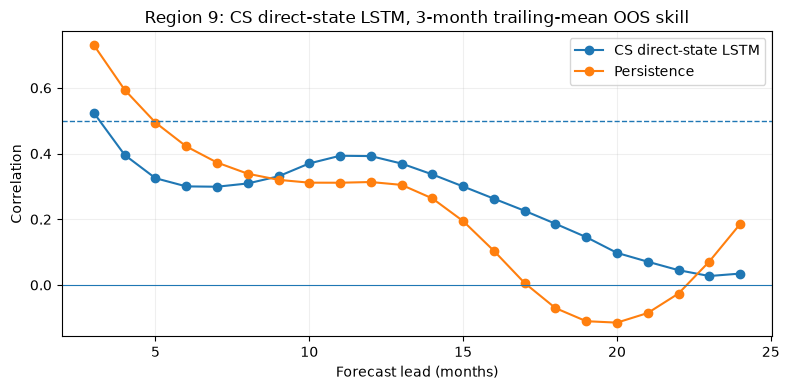

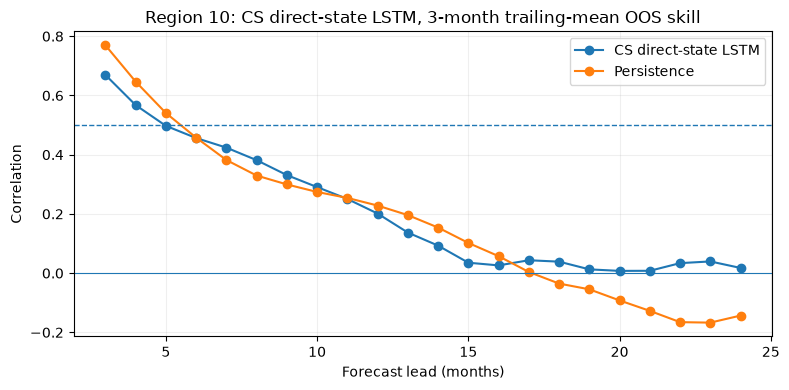

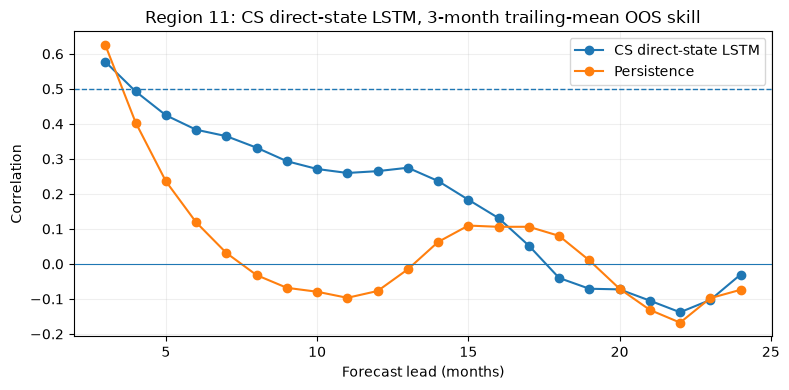

In [18]:
plot_skill_curves()

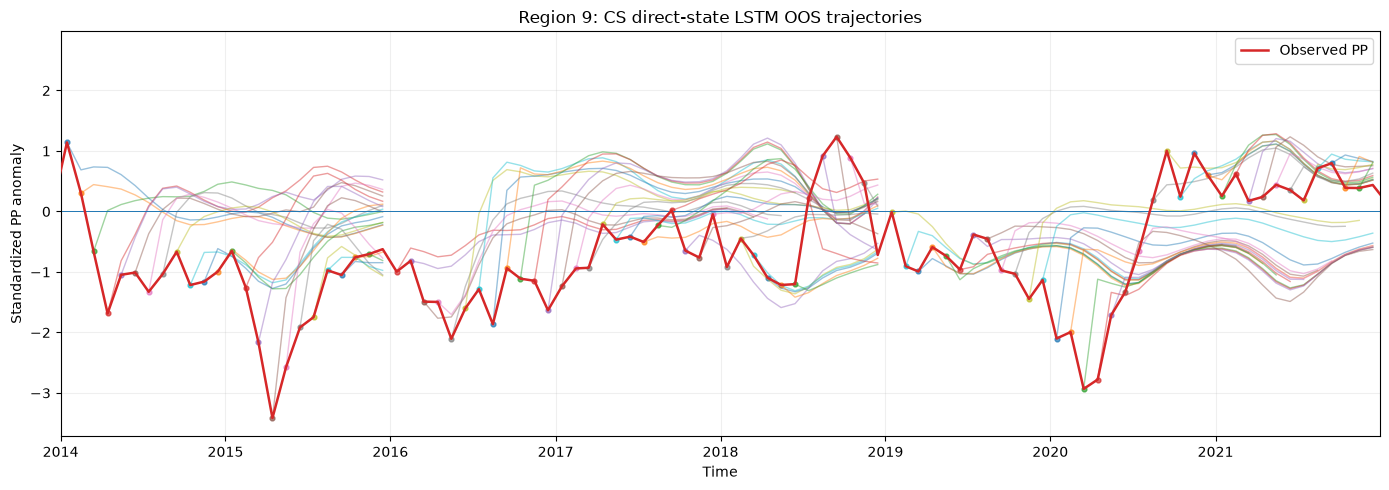

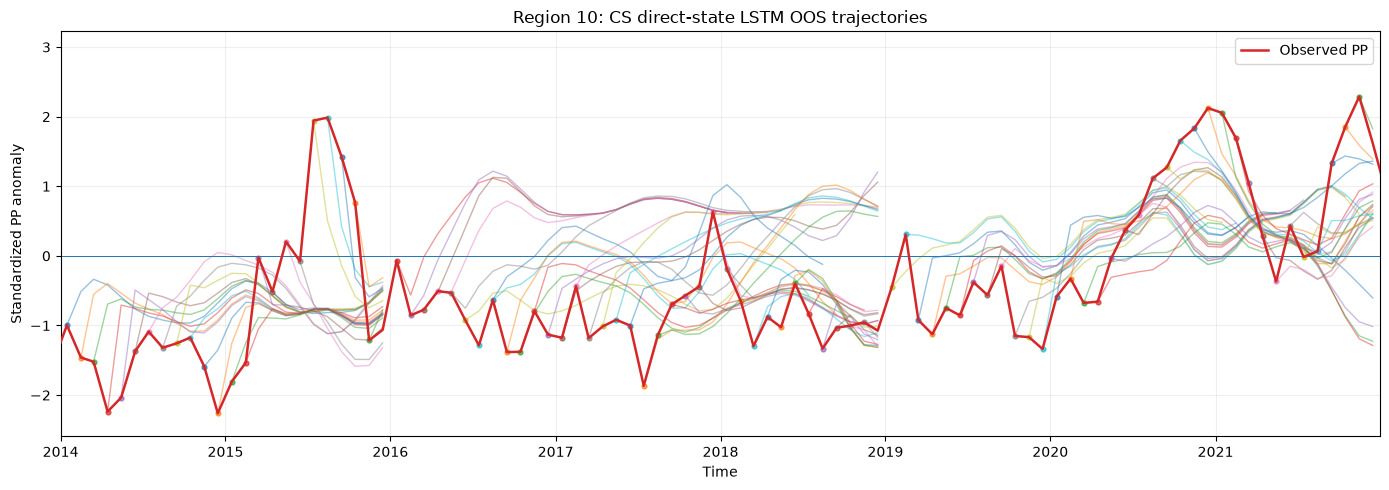

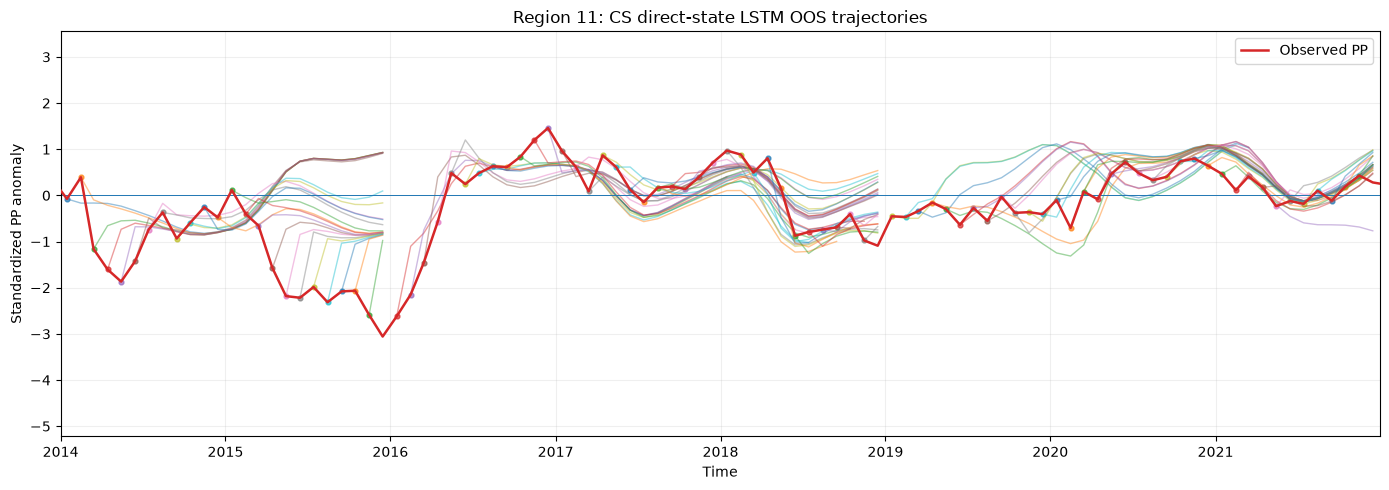

In [19]:
plot_spaghetti_region(9, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(10, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(11, every=1, start_date="2014-01-01", end_date="2021-12-31")

In [20]:
# Optional: confirm that the target calendar month changes with lead.
#
# Example for a March initialization:
example_initialization_month = 3
example_target_months = [
    (
        (
            example_initialization_month
            - 1
            + lead
        )
        % 12
        + 1
    )
    for lead in range(
        1,
        13,
    )
]

print(
    "Target months from a March initialization:",
    example_target_months,
)


Target months from a March initialization: [4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3]
